# Modelado Epidémico y Saturación del Sistema Hospitalario
### Modelo SIR/SEIR con Análisis de Capacidad Hospitalaria basado en Colas M/M/c

---

## Introducción

Este notebook implementa un marco de simulación que modela la propagación de una enfermedad infecciosa mediante el clásico **modelo SIR (Susceptible–Infectado–Recuperado)** y analiza la presión resultante sobre el sistema hospitalario a través de la **teoría de colas M/M/c**. Fue realizado mediante el uso de un LLM y mi directiva para poder modelar los diferentes agentes virales en las condiciones reportadas de Guatemala. Además, la implementación de modelos y partes del código están basados en modelos previos por otros científicos (citados abajo y en el informe).

### Marco Teórico

**Modelo SIR** (Kermack & McKendrick, 1927):  
La población se divide en tres compartimentos:
- **S** — Susceptible: individuos que pueden infectarse.
- **I** — Infectado: individuos actualmente contagiosos.
- **R** — Recuperado: individuos que se recuperaron y se asumen inmunes.

El sistema de EDOs que rige el modelo es:
$$\frac{dS}{dt} = -\beta \frac{S \cdot I}{N}$$
$$\frac{dI}{dt} = \beta \frac{S \cdot I}{N} - \gamma I$$
$$\frac{dR}{dt} = \gamma I$$

**Cola M/M/c** (Erlang-C):  
El hospital se modela como una cola multi-servidor donde:
- Los pacientes llegan a una tasa $\lambda(t)$ (proporcional a las nuevas infecciones).
- Hay $c$ camas/servidores, cada uno atendiendo pacientes a una tasa $\mu$.
- Utilización del sistema: $\rho(t) = \frac{\lambda(t)}{c \cdot \mu}$
  - $\rho < 1$ → sistema estable
  - $\rho \geq 1$ → sistema sobrecargado / saturado

---

## Estructura del Notebook

1. **Configuración e Importaciones** — Librerías y parámetros estéticos de graficación.
2. **Definición de Parámetros** — Todos los parámetros del modelo en un solo lugar.
3. **Sistema de EDOs SIR** — Definición y solución numérica del modelo.
4. **Capa Hospitalaria** — Mapeo de curvas epidémicas a métricas hospitalarias.
5. **Visualizaciones** — Curvas epidémicas, carga hospitalaria y utilización.
6. **Análisis de Escenarios** — Comparación de intervenciones (distanciamiento, vacunación, cuarentena).
7. **Métricas de Resumen** — Indicadores clave: pico de infecciones, duración de saturación, etc.

---
## Sección 1 — Importaciones y Configuración

In [ ]:
# ─── Librerías científicas estándar ──────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.integrate import solve_ivp
import pandas as pd

# ─── Parámetros estéticos de las gráficas ────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Librerías cargadas exitosamente.")

Librerías cargadas exitosamente.


---
## Sección 2 — Definición de Parámetros

Todos los parámetros se definen aquí en un único diccionario para facilitar su modificación sin tocar el código de las ecuaciones.

| Parámetro | Símbolo | Significado |
|---|---|---|
| `N` | $N$ | Población total |
| `beta` | $\beta$ | Tasa de transmisión (contactos × probabilidad por día) |
| `gamma` | $\gamma$ | Tasa de recuperación = 1 / (días promedio infeccioso) |
| `I0` | $I_0$ | Número inicial de individuos infectados |
| `p_hosp` | $p_h$ | Fracción de infectados que requieren hospitalización |
| `p_icu` | $p_{icu}$ | Fracción de infectados que requieren UCI |
| `hospital_beds` | $c$ | Número de camas hospitalarias disponibles |
| `avg_stay_days` | $1/\mu$ | Estadía hospitalaria promedio en días |
| `T` | — | Duración de la simulación en días |

In [ ]:
# ── Selección de enfermedad ───────────────────────────────────────────────────
# Opciones disponibles: "covid19", "measles" (sarampión), "sars", "ebola"
DISEASE = "ebola"

# Preconfiguración de parámetros por enfermedad basada en literatura epidemiológica
disease_presets = {
    "covid19": {
        "label":            "COVID-19 (cepa original)",
        "infectious_days":  10,
        "R0_empirical":     2.8,
        "p_hosp":           0.05,
        "p_icu":            0.01,
        "avg_stay_days":    10,
        "avg_icu_stay_days":14,
        "reference":        "WHO (2020); Jiménez-Soler et al. (2020), Front. Public Health",
    },
    "measles": {
        "label":            "Sarampión",
        "infectious_days":  8,
        "R0_empirical":     15.0,
        "p_hosp":           0.18,
        "p_icu":            0.05,
        "avg_stay_days":    5,
        "avg_icu_stay_days":10,
        "reference":        "Guerra et al. (2017), The Lancet Infectious Diseases",
    },
    "sars": {
        "label":            "SARS (2003)",
        "infectious_days":  7,
        "R0_empirical":     2.0,
        "p_hosp":           0.20,
        "p_icu":            0.07,
        "avg_stay_days":    14,
        "avg_icu_stay_days":21
    },
    "ebola": {
        "label":            "Ébola (África Occidental 2014)",
        "infectious_days":  6,
        "R0_empirical":     1.8,
        "p_hosp":           0.80,
        "p_icu":            0.40,
        "avg_stay_days":    12,
        "avg_icu_stay_days":15
    },
}

# ── Construcción de parámetros a partir del preset seleccionado ───────────────
preset = disease_presets[DISEASE]
gamma  = 1 / preset["infectious_days"]   # Tasa de recuperación [1/día]
beta   = preset["R0_empirical"] * gamma  # Tasa de transmisión derivada de R0

params = {
    "N":                18_125_000,           # Población total
    "beta":             beta,              # Tasa de transmisión
    "gamma":            gamma,             # Tasa de recuperación
    "I0":               10,               # Infectados iniciales
    "R0_init":          0,                # Recuperados iniciales
    "T":                200,              # Días de simulación
    "p_hosp":           preset["p_hosp"],
    "p_icu":            preset["p_icu"],
    "hospital_beds":    8597,              # Camas hospitalarias disponibles
    "icu_beds":         453,               # Camas de UCI disponibles
    "avg_stay_days":    preset["avg_stay_days"],
    "avg_icu_stay_days":preset["avg_icu_stay_days"],
}

# Parámetros derivados a partir de los anteriores
params["S0"]          = params["N"] - params["I0"] - params["R0_init"]
params["R0_epidemio"] = params["beta"] / params["gamma"]   # Número reproductivo básico
params["mu_hosp"]     = 1 / params["avg_stay_days"]        # Tasa de servicio hospitalario
params["mu_icu"]      = 1 / params["avg_icu_stay_days"]    # Tasa de servicio UCI

# Vectores de tiempo para la integración numérica
t_span = (0, params["T"])
t_eval = np.linspace(0, params["T"], params["T"] * 2)

print(f"Enfermedad: {preset['label']}")
print(f"  β = {params['beta']:.4f}, γ = {params['gamma']:.4f}, R₀ = {params['R0_epidemio']:.1f}")
print(f"  Referencia: {preset['reference']}")

Enfermedad: Ébola (África Occidental 2014)
  β = 0.3000, γ = 0.1667, R₀ = 1.8
  Referencia: Berge et al. (2015), BioMed Res. Int.; WHO Ebola Response Team (2014)


---
## Sección 3 — Sistema de EDOs SIR

Se define el modelo SIR como función de Python y se resuelve numéricamente con `scipy.integrate.solve_ivp` (método Runge-Kutta 4/5 por defecto).

El sistema de EDOs es:
$$\frac{dS}{dt} = -\beta \frac{S \cdot I}{N}, \quad \frac{dI}{dt} = \beta \frac{S \cdot I}{N} - \gamma I, \quad \frac{dR}{dt} = \gamma I$$

In [ ]:
def sir_ode(t, y, beta, gamma, N):
    """
    Sistema de ecuaciones diferenciales del modelo SIR.

    Parámetros
    ----------
    t     : float — tiempo actual (requerido por solve_ivp, no se usa explícitamente)
    y     : array — vector de estado actual [S, I, R]
    beta  : float — tasa de transmisión [1/día]
    gamma : float — tasa de recuperación [1/día]
    N     : int   — población total

    Retorna
    -------
    [dS/dt, dI/dt, dR/dt] — derivadas en el tiempo t
    """
    S, I, R = y  # Desempaque del vector de estado

    # Fuerza de infección: probabilidad de que un susceptible contacte a un infectado
    fuerza_infeccion = beta * S * I / N

    dS_dt = -fuerza_infeccion               # S disminuye al contagiarse
    dI_dt =  fuerza_infeccion - gamma * I   # I gana nuevos casos, pierde recuperados
    dR_dt =  gamma * I                      # R crece con los recuperados

    return [dS_dt, dI_dt, dR_dt]


def run_sir(params, beta_override=None):
    """
    Resuelve el sistema de EDOs SIR y retorna los resultados en un DataFrame.

    Parámetros
    ----------
    params        : dict  — diccionario de parámetros del modelo
    beta_override : float — si se provee, reemplaza params['beta'] (para escenarios)

    Retorna
    -------
    df : pd.DataFrame con columnas [t, S, I, R]
    """
    beta  = beta_override if beta_override is not None else params["beta"]
    gamma = params["gamma"]
    N     = params["N"]

    y0 = [params["S0"], params["I0"], params["R0_init"]]  # Condiciones iniciales

    # Integración numérica con Runge-Kutta 4(5)
    # solve_ivp ajusta automáticamente el tamaño de paso para cumplir la tolerancia de error
    sol = solve_ivp(
        fun=sir_ode,
        t_span=t_span,
        y0=y0,
        args=(beta, gamma, N),
        t_eval=t_eval,
        method="RK45",
        dense_output=False,
    )

    # Organizar resultados en un DataFrame
    df = pd.DataFrame({
        "t": sol.t,
        "S": sol.y[0],
        "I": sol.y[1],
        "R": sol.y[2],
    })
    return df


# Ejecución de la simulación SIR base
df_baseline = run_sir(params)
print(f"Simulación base completada. Pasos: {len(df_baseline)}")
print(f"  Pico de infectados:     {df_baseline['I'].max():,.0f}  en el día {df_baseline.loc[df_baseline['I'].idxmax(), 't']:.1f}")
print(f"  Total de afectados:     {(params['N'] - df_baseline['S'].iloc[-1]):,.0f}  ({(params['N'] - df_baseline['S'].iloc[-1])/params['N']*100:.1f}% de la población)")

Simulación base completada. Pasos: 400
  Pico de infectados:     2,143,563  en el día 104.8
  Total de afectados:     13,260,854  (73.2% de la población)


---
## Sección 4 — Capa Hospitalaria

Se mapea la salida epidémica a métricas hospitalarias mediante tres pasos:

1. **Ocupación hospitalaria** — una fracción de los casos activos ocupa camas:
   $H(t) = p_h \cdot I(t)$

2. **Tasa de llegada hospitalaria** — nuevos pacientes por día (proporcional a nuevas infecciones):
   $\lambda(t) = p_h \cdot \beta \cdot \frac{S(t) \cdot I(t)}{N}$

3. **Utilización del sistema** (métrica de cola M/M/c):
   $\rho(t) = \frac{\lambda(t)}{c \cdot \mu}$
   donde $c$ = número de camas y $\mu = 1/\text{estadía\_promedio}$ es la tasa de servicio.

In [ ]:
def compute_hospital_metrics(df, params, beta_override=None):
    """
    Deriva métricas hospitalarias y de utilización M/M/c a partir de las curvas epidémicas.

    Parámetros
    ----------
    df            : pd.DataFrame — salida de run_sir() [t, S, I, R]
    params        : dict         — parámetros del modelo
    beta_override : float        — beta alternativo para escenarios

    Retorna
    -------
    df : mismo DataFrame con columnas hospitalarias adicionales
    """
    df = df.copy()  # Se evita modificar el DataFrame original

    beta   = beta_override if beta_override is not None else params["beta"]
    N      = params["N"]
    p_h    = params["p_hosp"]
    p_icu  = params["p_icu"]
    c      = params["hospital_beds"]
    c_icu  = params["icu_beds"]
    mu     = params["mu_hosp"]
    mu_icu = params["mu_icu"]

    # ── Paso 1: Ocupación hospitalaria (camas en uso en cada instante) ─────────
    # H(t) = p_h * I(t): fracción de casos activos que están hospitalizados
    df["H"]   = p_h   * df["I"]   # Hospitalización general
    df["ICU"] = p_icu * df["I"]   # Ocupación de UCI

    # ── Paso 2: Tasa de llegada λ(t) ─────────────────────────────────────────
    # Admisiones nuevas por día = fracción de nuevas infecciones que se hospitalizan
    nuevas_infecciones = beta * df["S"] * df["I"] / N
    df["lambda_hosp"] = p_h   * nuevas_infecciones  # Llegadas a hospitalización [pacientes/día]
    df["lambda_icu"]  = p_icu * nuevas_infecciones  # Llegadas a UCI [pacientes/día]

    # ── Paso 3: Utilización de la cola M/M/c → ρ(t) ──────────────────────────
    # ρ = λ / (c * μ)
    # c * μ = capacidad total de servicio del sistema [pacientes/día]
    # ρ < 1 → sistema estable;  ρ ≥ 1 → sistema saturado
    capacidad_total_hosp = c     * mu
    capacidad_total_icu  = c_icu * mu_icu

    df["rho_hosp"] = df["lambda_hosp"] / capacidad_total_hosp
    df["rho_icu"]  = df["lambda_icu"]  / capacidad_total_icu

    # ── Indicador de saturación ───────────────────────────────────────────────
    # Variable binaria: ¿está el sistema sobrecargado en este paso de tiempo?
    df["hosp_saturado"] = df["rho_hosp"] >= 1.0
    df["icu_saturado"]  = df["rho_icu"]  >= 1.0

    return df


# Aplicar métricas hospitalarias a la simulación base
df_baseline = compute_hospital_metrics(df_baseline, params)

# ── Estadísticas de resumen ────────────────────────────────────────────────────
dt = t_eval[1] - t_eval[0]  # Tamaño del paso de tiempo

pico_H        = df_baseline["H"].max()
pico_ICU      = df_baseline["ICU"].max()
pico_rho      = df_baseline["rho_hosp"].max()
dias_sat      = df_baseline["hosp_saturado"].sum() * dt
dias_sat_icu  = df_baseline["icu_saturado"].sum() * dt

print("Métricas Hospitalarias — Escenario Base")
print(f"  Pico de hospitalizados (H):    {pico_H:,.0f}  camas requeridas")
print(f"  Camas hospitalarias disponibles: {params['hospital_beds']}")
print(f"  Pico de pacientes en UCI:      {pico_ICU:,.0f}  camas requeridas")
print(f"  Camas de UCI disponibles:      {params['icu_beds']}")
print(f"  Utilización máxima ρ:          {pico_rho:.2f}  {'⚠ SATURADO' if pico_rho >= 1 else '✓ dentro de capacidad'}")
print(f"  Días con hospital saturado:    {dias_sat:.1f} días")
print(f"  Días con UCI saturada:         {dias_sat_icu:.1f} días")

Métricas Hospitalarias — Escenario Base
  Pico de hospitalizados (H):    1,714,850  camas requeridas
  Camas hospitalarias disponibles: 8597
  Pico de pacientes en UCI:      857,425  camas requeridas
  Camas de UCI disponibles:      453
  Utilización máxima ρ:          437.83  ⚠ SATURADO
  Días con hospital saturado:    135.3 días
  Días con UCI saturada:         175.9 días


---
## Sección 5 — Visualización: Curvas Epidémicas Base

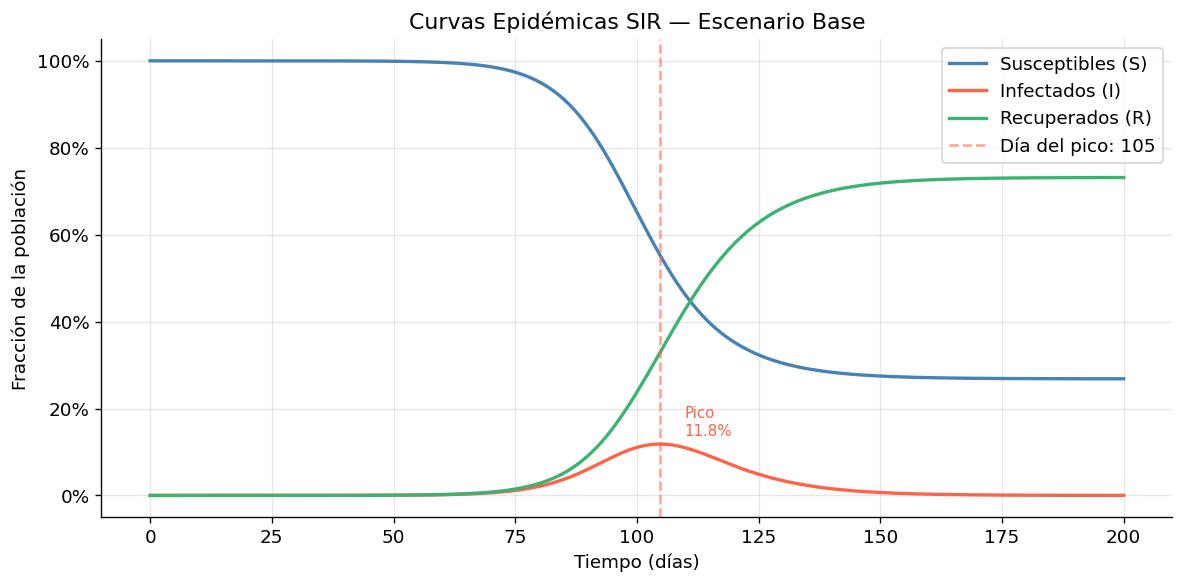

In [ ]:
def plot_sir_curves(df, params, titulo="Curvas Epidémicas SIR — Escenario Base"):
    """
    Grafica los tres compartimentos del modelo SIR a lo largo del tiempo.

    S (azul), I (rojo), R (verde) se muestran como fracción de N
    para que las curvas sean independientes de la escala y comparables entre escenarios.
    """
    N = params["N"]
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(df["t"], df["S"] / N, color="steelblue",      lw=2, label="Susceptibles (S)")
    ax.plot(df["t"], df["I"] / N, color="tomato",          lw=2, label="Infectados (I)")
    ax.plot(df["t"], df["R"] / N, color="mediumseagreen",  lw=2, label="Recuperados (R)")

    # Marcador del pico epidémico
    pico_t = df.loc[df["I"].idxmax(), "t"]
    pico_I = df["I"].max() / N
    ax.axvline(pico_t, color="tomato", ls="--", alpha=0.6, label=f"Día del pico: {pico_t:.0f}")
    ax.annotate(f"Pico\n{pico_I*100:.1f}%",
                xy=(pico_t, pico_I), xytext=(pico_t + 5, pico_I + 0.02),
                fontsize=9, color="tomato")

    ax.set_xlabel("Tiempo (días)")
    ax.set_ylabel("Fracción de la población")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(titulo)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_sir_curves(df_baseline, params)

---
## Sección 6 — Ocupación Hospitalaria y Carga en UCI

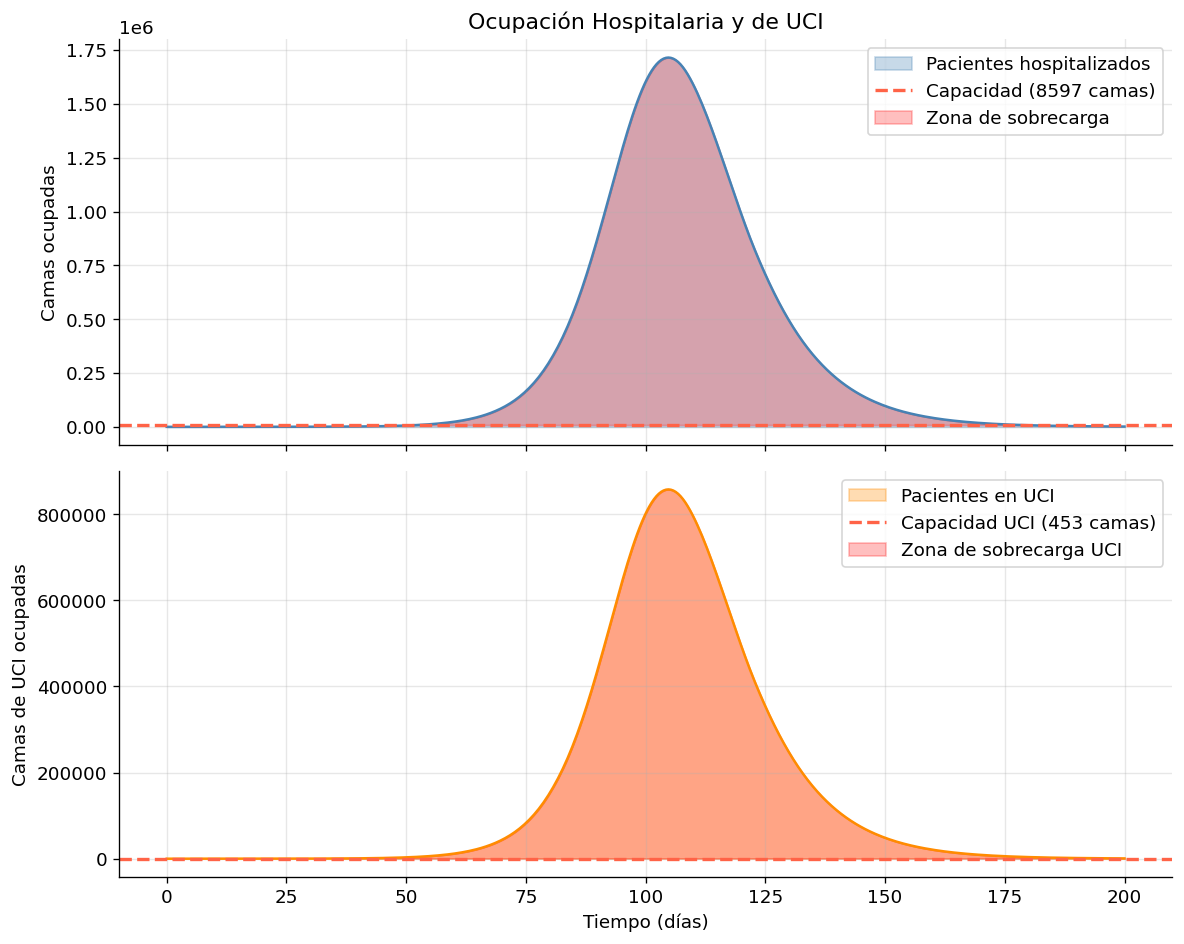

In [ ]:
def plot_hospital_load(df, params, titulo="Ocupación Hospitalaria y de UCI"):
    """
    Grafica pacientes hospitalizados (H) y ocupación de UCI frente a los umbrales de capacidad.
    Las zonas de saturación se resaltan en rojo.
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # ── Panel superior: hospitalización general ───────────────────────────────
    ax1 = axes[0]
    ax1.fill_between(df["t"], df["H"],
                     alpha=0.3, color="steelblue", label="Pacientes hospitalizados")
    ax1.plot(df["t"], df["H"], color="steelblue", lw=1.5)

    # Línea de capacidad máxima
    ax1.axhline(params["hospital_beds"], color="tomato", ls="--", lw=2,
                label=f"Capacidad ({params['hospital_beds']} camas)")

    # Zona de sobrecarga (cuando H supera la capacidad)
    ax1.fill_between(df["t"], df["H"], params["hospital_beds"],
                     where=df["H"] > params["hospital_beds"],
                     alpha=0.25, color="red", label="Zona de sobrecarga")

    ax1.set_ylabel("Camas ocupadas")
    ax1.set_title(titulo)
    ax1.legend(loc="upper right")

    # ── Panel inferior: UCI ───────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.fill_between(df["t"], df["ICU"],
                     alpha=0.3, color="darkorange", label="Pacientes en UCI")
    ax2.plot(df["t"], df["ICU"], color="darkorange", lw=1.5)

    ax2.axhline(params["icu_beds"], color="tomato", ls="--", lw=2,
                label=f"Capacidad UCI ({params['icu_beds']} camas)")

    ax2.fill_between(df["t"], df["ICU"], params["icu_beds"],
                     where=df["ICU"] > params["icu_beds"],
                     alpha=0.25, color="red", label="Zona de sobrecarga UCI")

    ax2.set_xlabel("Tiempo (días)")
    ax2.set_ylabel("Camas de UCI ocupadas")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


plot_hospital_load(df_baseline, params)

---
## Sección 7 — Utilización del Sistema de Salud ρ(t)

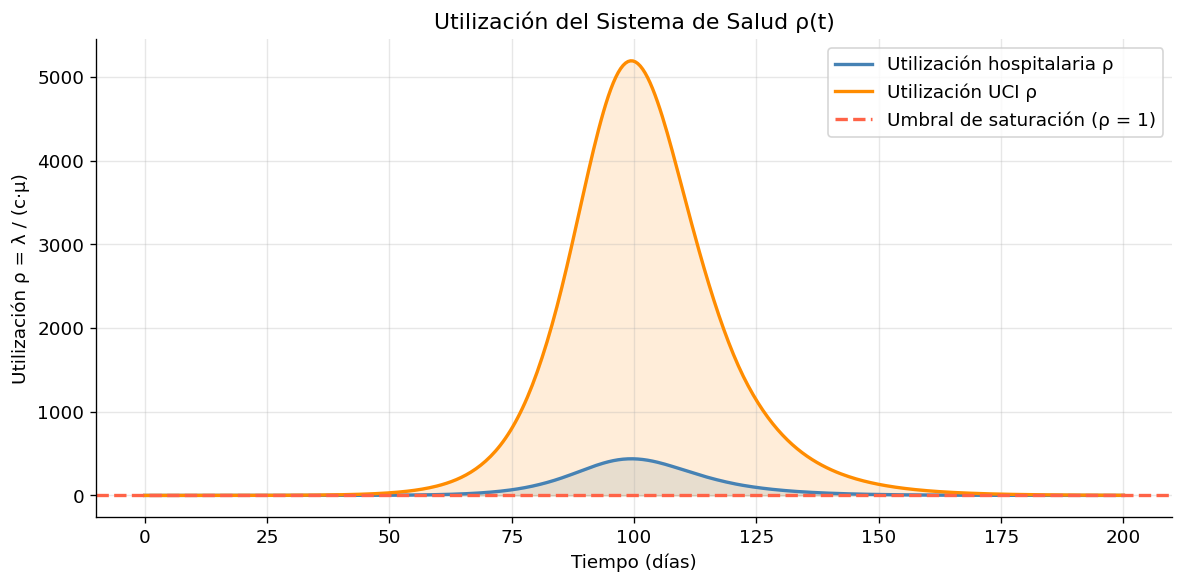

In [ ]:
def plot_utilization(df, titulo="Utilización del Sistema de Salud ρ(t)"):
    """
    Grafica la métrica de utilización M/M/c ρ(t) para hospitalización general y UCI.

    La línea punteada horizontal en ρ=1 marca el umbral de saturación:
    - Por debajo de 1 → el sistema absorbe la carga de pacientes
    - Por encima de 1 → el sistema está saturado (no puede atender adecuadamente)
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(df["t"], df["rho_hosp"], lw=2, color="steelblue",  label="Utilización hospitalaria ρ")
    ax.plot(df["t"], df["rho_icu"],  lw=2, color="darkorange", label="Utilización UCI ρ")

    # Umbral de saturación
    ax.axhline(1.0, color="tomato", ls="--", lw=2, label="Umbral de saturación (ρ = 1)")

    # Zonas de sobrecarga sombreadas
    ax.fill_between(df["t"], df["rho_hosp"], 1.0,
                    where=df["rho_hosp"] > 1.0, alpha=0.15, color="steelblue")
    ax.fill_between(df["t"], df["rho_icu"], 1.0,
                    where=df["rho_icu"] > 1.0, alpha=0.15, color="darkorange")

    ax.set_xlabel("Tiempo (días)")
    ax.set_ylabel("Utilización ρ = λ / (c·μ)")
    ax.set_title(titulo)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_utilization(df_baseline)

---
## Sección 8 — Análisis de Escenarios: Políticas de Intervención

Se modelan cuatro escenarios **modificando la tasa de transmisión efectiva β**:

| Escenario | β | Justificación |
|---|---|---|
| Base | β original | Sin intervención |
| Distanciamiento social | β × 0.55 | Reducción de contactos en 45% |
| Vacunación moderada | β × 0.40 | Reducción del grupo susceptible (~60% cobertura) |
| Confinamiento estricto | β × 0.20 | Reducción severa de contactos (80%) |

> **Nota:** En un modelo más detallado, la vacunación reduciría directamente S₀ en vez de β. Aquí se aproximan ambos efectos mediante un β efectivo para mantener el modelo tratable.

In [ ]:
# ─── Definición de escenarios ────────────────────────────────────────────────
# Cada escenario especifica un nombre, un multiplicador sobre β y atributos visuales
beta_base = params["beta"]  # β de referencia (sin intervención)

escenarios = [
    {
        "name":        "Base (sin intervención)",
        "beta_mult":   1.00,             # β al 100%
        "color":       "tomato",
        "linestyle":   "-",
    },
    {
        "name":        "Distanciamiento social (−45% contactos)",
        "beta_mult":   0.55,             # β al 55%
        "color":       "steelblue",
        "linestyle":   "--",
    },
    {
        "name":        "Vacunación moderada (~60% cobertura)",
        "beta_mult":   0.40,             # β al 40% (reducción efectiva de R₀)
        "color":       "mediumseagreen",
        "linestyle":   "-.",
    },
    {
        "name":        "Confinamiento estricto (−80% contactos)",
        "beta_mult":   0.20,             # β al 20%
        "color":       "mediumpurple",
        "linestyle":   ":",
    },
]

# ─── Ejecución de todos los escenarios ───────────────────────────────────────
results = []
for scen in escenarios:
    beta_efectivo = beta_base * scen["beta_mult"]       # β escalado por el multiplicador
    R0_efectivo   = beta_efectivo / params["gamma"]     # R₀ resultante

    df_scen = run_sir(params, beta_override=beta_efectivo)
    df_scen = compute_hospital_metrics(df_scen, params, beta_override=beta_efectivo)

    results.append({
        "scenario": scen,
        "df":       df_scen,
        "beta":     beta_efectivo,
        "R0":       R0_efectivo,
    })

    print(f"  [{scen['name']}] β={beta_efectivo:.3f}, R₀={R0_efectivo:.2f}, "
          f"pico I={df_scen['I'].max():,.0f}, pico H={df_scen['H'].max():,.0f}")

print("\nTodos los escenarios calculados.")

  [Base (sin intervención)] β=0.300, R₀=1.80, pico I=2,143,563, pico H=1,714,850
  [Distanciamiento social (−45% contactos)] β=0.165, R₀=0.99, pico I=10, pico H=8
  [Vacunación moderada (~60% cobertura)] β=0.120, R₀=0.72, pico I=10, pico H=8
  [Confinamiento estricto (−80% contactos)] β=0.060, R₀=0.36, pico I=10, pico H=8

Todos los escenarios calculados.


---
## Sección 9 — Gráficas de Comparación de Escenarios

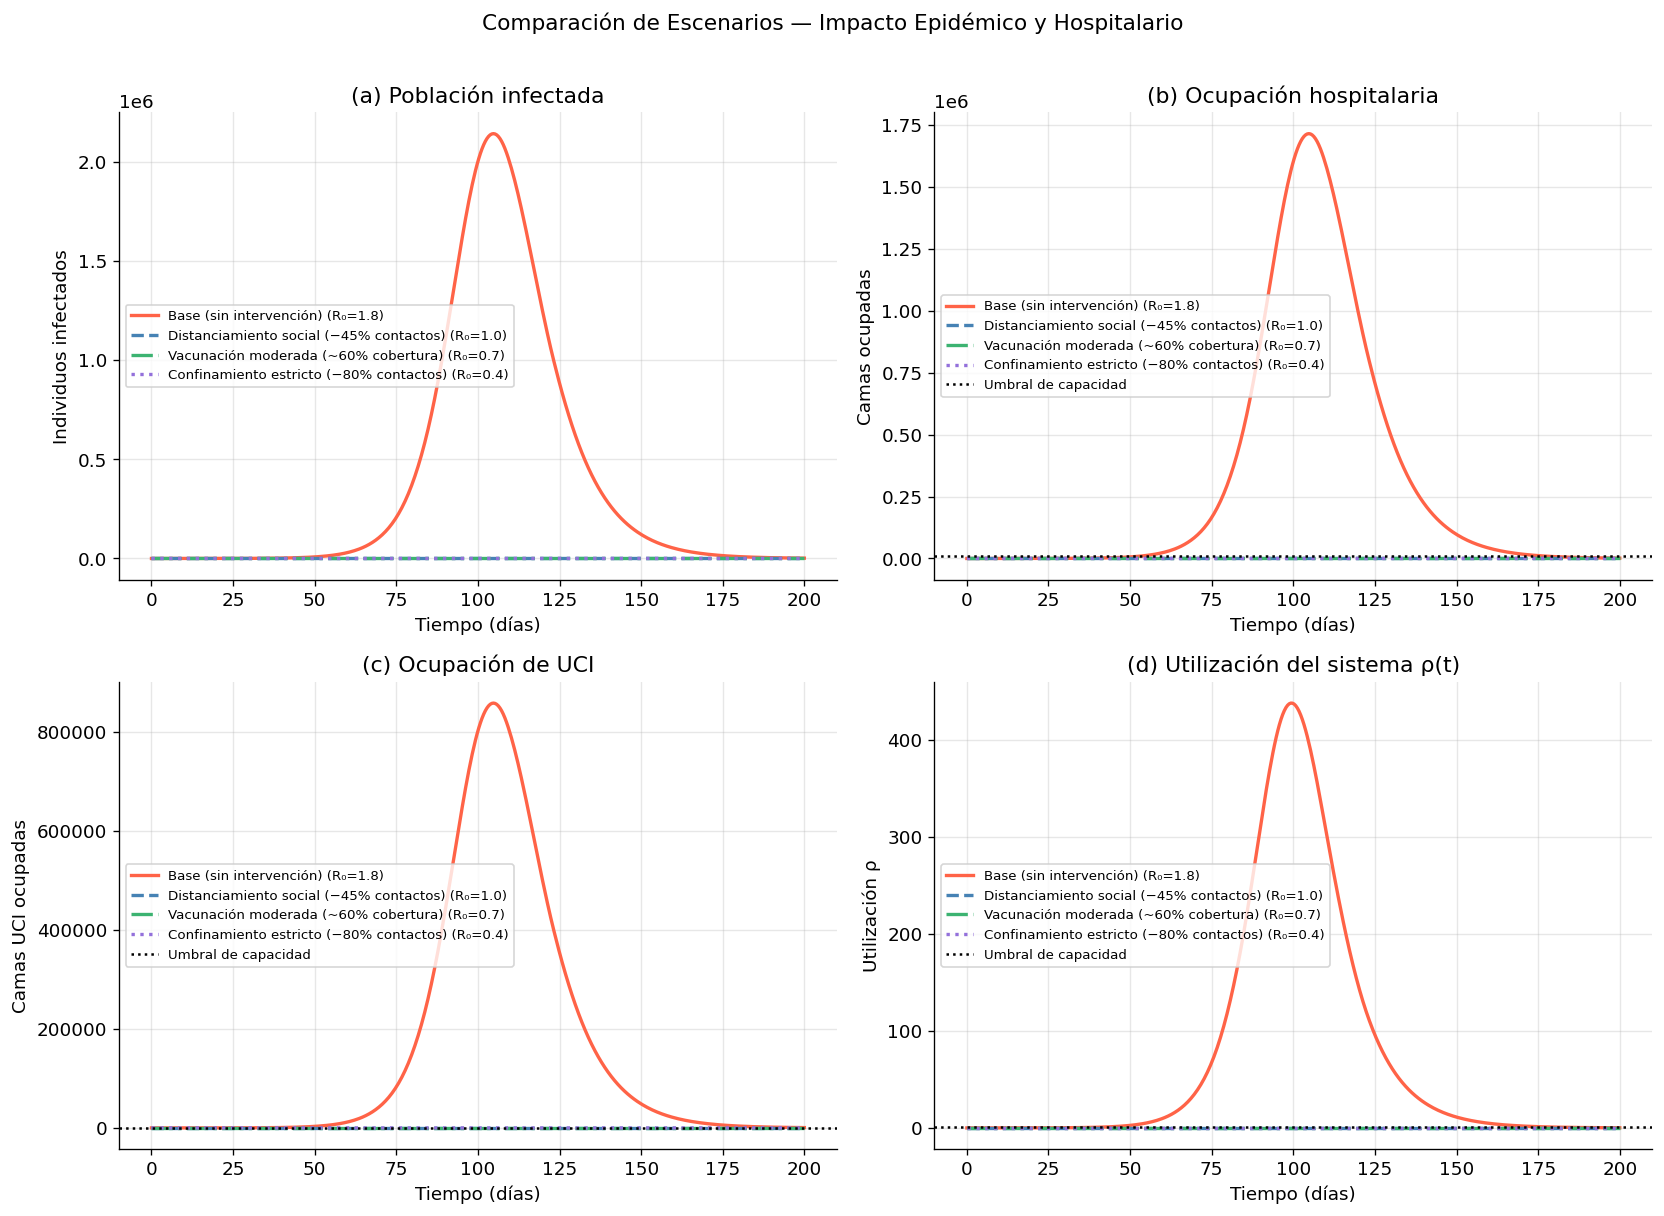

In [ ]:
def plot_scenario_comparison(results, params):
    """
    Figura de comparación con cuatro paneles:
    (a) Curvas de infectados        (b) Ocupación hospitalaria
    (c) Ocupación de UCI            (d) Utilización del sistema ρ
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    # Configuración de cada panel: columna de datos, etiqueta del eje y, título, umbral
    panel_configs = [
        {"col": "I",         "ylabel": "Individuos infectados",  "title": "(a) Población infectada",
         "hline": None},
        {"col": "H",         "ylabel": "Camas ocupadas",         "title": "(b) Ocupación hospitalaria",
         "hline": params["hospital_beds"]},
        {"col": "ICU",       "ylabel": "Camas UCI ocupadas",     "title": "(c) Ocupación de UCI",
         "hline": params["icu_beds"]},
        {"col": "rho_hosp",  "ylabel": "Utilización ρ",          "title": "(d) Utilización del sistema ρ(t)",
         "hline": 1.0},
    ]

    for ax, cfg in zip(axes, panel_configs):
        for res in results:
            scen = res["scenario"]
            df   = res["df"]
            ax.plot(df["t"], df[cfg["col"]],
                    color=scen["color"],
                    ls=scen["linestyle"],
                    lw=2,
                    label=f"{scen['name']} (R₀={res['R0']:.1f})")

        # Línea de capacidad / umbral de saturación
        if cfg["hline"] is not None:
            ax.axhline(cfg["hline"], color="black", ls=":", lw=1.5,
                       label="Umbral de capacidad")

        ax.set_xlabel("Tiempo (días)")
        ax.set_ylabel(cfg["ylabel"])
        ax.set_title(cfg["title"])
        ax.legend(fontsize=8)

    fig.suptitle("Comparación de Escenarios — Impacto Epidémico y Hospitalario", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


plot_scenario_comparison(results, params)

---
## Sección 10 — Análisis de Sensibilidad: Efecto de β sobre el Pico de Infecciones

Se varía β en un rango para observar cómo cambia el pico de infectados.  
Esto evidencia la naturaleza **no lineal** de la dinámica epidémica.

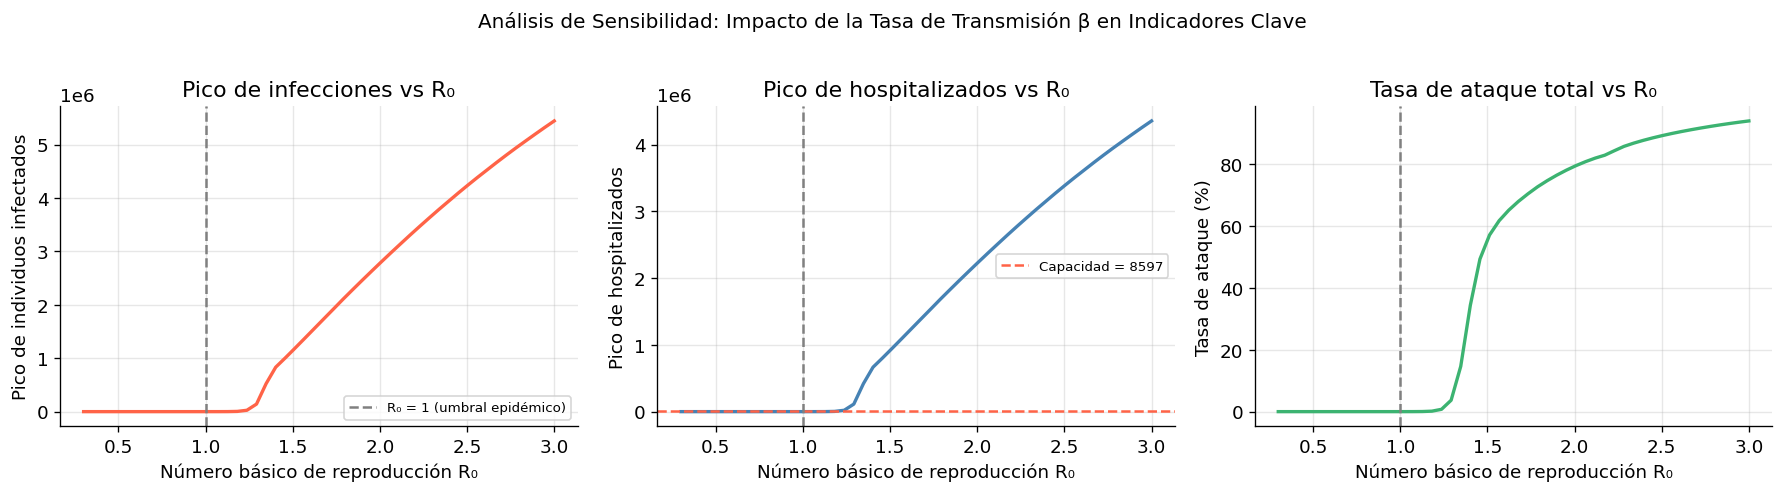

In [ ]:
# ─── Barrido de β entre 0.05 y 0.50 ─────────────────────────────────────────
# Se varía β manteniendo γ constante — esto modifica R₀ = β/γ
beta_valores = np.linspace(0.05, 0.50, 50)  # 50 valores equiespaciados de β

lista_pico_I      = []
lista_pico_H      = []
lista_tasa_ataque = []

for b in beta_valores:
    df_tmp = run_sir(params, beta_override=b)
    df_tmp = compute_hospital_metrics(df_tmp, params, beta_override=b)
    lista_pico_I.append(df_tmp["I"].max())
    lista_pico_H.append(df_tmp["H"].max())
    lista_tasa_ataque.append((params["N"] - df_tmp["S"].iloc[-1]) / params["N"])

# R₀ correspondiente a cada β para el eje x
R0_valores = beta_valores / params["gamma"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Pico de infectados vs R₀
axes[0].plot(R0_valores, lista_pico_I, color="tomato", lw=2)
axes[0].axvline(1.0, color="gray", ls="--", label="R₀ = 1 (umbral epidémico)")
axes[0].set_xlabel("Número básico de reproducción R₀")
axes[0].set_ylabel("Pico de individuos infectados")
axes[0].set_title("Pico de infecciones vs R₀")
axes[0].legend(fontsize=8)

# Panel 2: Pico de hospitalizados vs R₀
axes[1].plot(R0_valores, lista_pico_H, color="steelblue", lw=2)
axes[1].axhline(params["hospital_beds"], color="tomato", ls="--",
                label=f"Capacidad = {params['hospital_beds']}")
axes[1].axvline(1.0, color="gray", ls="--")
axes[1].set_xlabel("Número básico de reproducción R₀")
axes[1].set_ylabel("Pico de hospitalizados")
axes[1].set_title("Pico de hospitalizados vs R₀")
axes[1].legend(fontsize=8)

# Panel 3: Tasa de ataque (fracción total infectada) vs R₀
axes[2].plot(R0_valores, [a*100 for a in lista_tasa_ataque], color="mediumseagreen", lw=2)
axes[2].axvline(1.0, color="gray", ls="--")
axes[2].set_xlabel("Número básico de reproducción R₀")
axes[2].set_ylabel("Tasa de ataque (%)")
axes[2].set_title("Tasa de ataque total vs R₀")

plt.suptitle("Análisis de Sensibilidad: Impacto de la Tasa de Transmisión β en Indicadores Clave",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Sección 11 — Tabla de Métricas de Resumen

In [ ]:
def summarize_scenario(res, params, dt):
    """
    Calcula un diccionario de métricas epidémicas y hospitalarias para un escenario.

    Parámetros
    ----------
    res    : dict  — una entrada de la lista results
    params : dict  — parámetros del modelo
    dt     : float — tamaño de paso de tiempo para calcular duraciones

    Retorna
    -------
    dict con estadísticas de resumen
    """
    df = res["df"]
    N  = params["N"]

    idx_pico_I = df["I"].idxmax()
    idx_pico_H = df["H"].idxmax()

    return {
        "Escenario":                    res["scenario"]["name"],
        "R₀ efectivo":                  round(res["R0"], 2),
        "Pico de infectados":           int(df["I"].max()),
        "Día del pico (infectados)":    round(df.loc[idx_pico_I, "t"], 1),
        "Pico de hospitalizados":       int(df["H"].max()),
        "Capacidad hosp. superada":     "Sí" if df["H"].max() > params["hospital_beds"] else "No",
        "Pico UCI":                     int(df["ICU"].max()),
        "Capacidad UCI superada":       "Sí" if df["ICU"].max() > params["icu_beds"] else "No",
        "Pico ρ (hospital)":            round(df["rho_hosp"].max(), 3),
        "Días en sobrecarga":           round(df["hosp_saturado"].sum() * dt, 1),
        "Tasa de ataque total (%)": round((N - df["S"].iloc[-1]) / N * 100, 1),
    }


dt = t_eval[1] - t_eval[0]

filas_resumen = [summarize_scenario(res, params, dt) for res in results]
summary_df    = pd.DataFrame(filas_resumen).set_index("Escenario")

# Visualización de la tabla
print("=== Resumen Comparativo de Escenarios ===")
print(summary_df.T.to_string())
summary_df

=== Resumen Comparativo de Escenarios ===
Escenario                 Base (sin intervención) Distanciamiento social (−45% contactos) Vacunación moderada (~60% cobertura) Confinamiento estricto (−80% contactos)
R₀ efectivo                                   1.8                                    0.99                                 0.72                                    0.36
Pico de infectados                        2143562                                      10                                   10                                      10
Día del pico (infectados)                   104.8                                     0.0                                  0.0                                     0.0
Pico de hospitalizados                    1714850                                       8                                    8                                       8
Capacidad hosp. superada                       Sí                                      No                                  

,R₀ efectivo,Pico de infectados,Día del pico (infectados),Pico de hospitalizados,Capacidad hosp. superada,Pico UCI,Capacidad UCI superada,Pico ρ (hospital),Días en sobrecarga,Tasa de ataque total (%)
Escenario,,,,,,,,,,
Base (sin intervención),1.80,2143562,104.8,1714850,Sí,857425,Sí,437.832,135.3,73.2
Distanciamiento social (−45% contactos),0.99,10,0.0,8,No,4,No,0.002,0.0,0.0
Vacunación moderada (~60% cobertura),0.72,10,0.0,8,No,4,No,0.001,0.0,0.0
Confinamiento estricto (−80% contactos),0.36,10,0.0,8,No,4,No,0.001,0.0,0.0


---
## Sección 12 — Extensión SEIR (Opcional)

El **modelo SEIR** agrega un compartimento **Expuesto (E)** que representa individuos infectados pero aún no contagiosos (el *período de latencia*).

$$\frac{dS}{dt} = -\beta \frac{S \cdot I}{N}$$
$$\frac{dE}{dt} = \beta \frac{S \cdot I}{N} - \sigma E$$
$$\frac{dI}{dt} = \sigma E - \gamma I$$
$$\frac{dR}{dt} = \gamma I$$

Donde $\sigma = 1/\text{días\_incubación}$ es la tasa de progresión de expuesto a infeccioso.

El modelo SEIR produce un pico epidémico **más lento, suavizado y levemente retrasado** respecto al SIR.

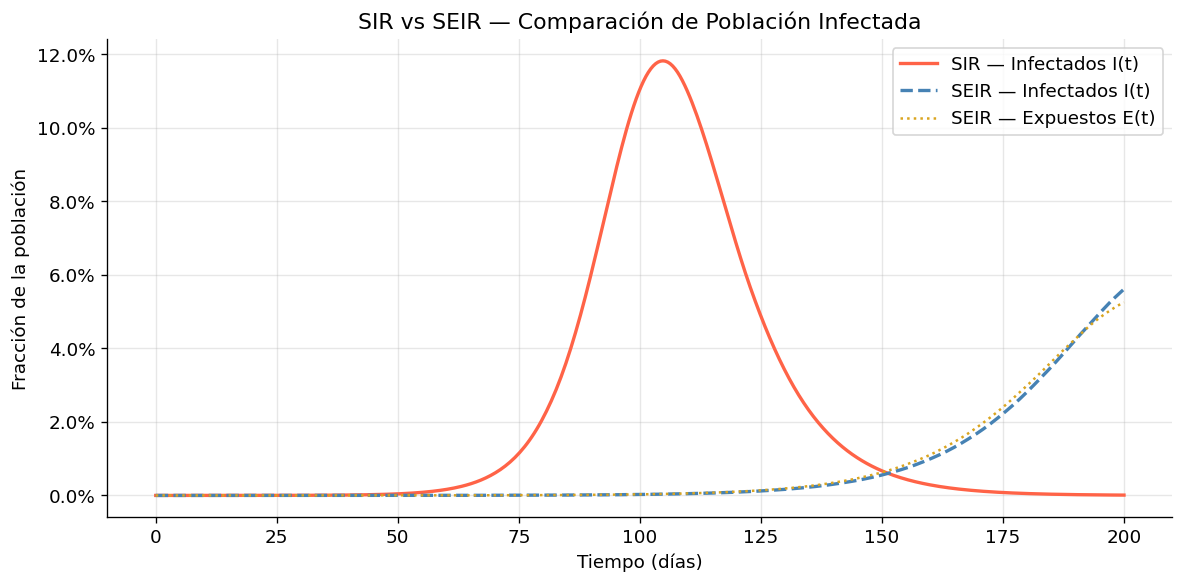

Pico SIR:  2,143,563 infectados en el día 104.8
Pico SEIR: 1,017,332 infectados en el día 200.0


In [ ]:
# ─── Parámetros del modelo SEIR ──────────────────────────────────────────────
seir_params = {
    "incubation_days": 5,   # Días promedio desde la exposición hasta ser infeccioso
}
seir_params["sigma"] = 1 / seir_params["incubation_days"]  # Tasa de progresión E → I


def seir_ode(t, y, beta, sigma, gamma, N):
    """
    Sistema de ecuaciones diferenciales del modelo SEIR.

    Parámetros
    ----------
    t     : float — tiempo actual
    y     : array — vector de estado [S, E, I, R]
    beta  : float — tasa de transmisión
    sigma : float — tasa de progresión de Expuesto a Infeccioso (1/días_incubación)
    gamma : float — tasa de recuperación
    N     : int   — población total

    Retorna
    -------
    [dS/dt, dE/dt, dI/dt, dR/dt]
    """
    S, E, I, R = y

    fuerza_infeccion = beta * S * I / N

    dS_dt = -fuerza_infeccion                # Susceptibles pasan a Expuestos
    dE_dt =  fuerza_infeccion - sigma * E    # Expuestos progresan a Infecciosos
    dI_dt =  sigma * E - gamma * I           # Infecciosos se recuperan
    dR_dt =  gamma * I

    return [dS_dt, dE_dt, dI_dt, dR_dt]


def run_seir(params, seir_params):
    """
    Resuelve el sistema de EDOs SEIR.
    Se asume el mismo número de expuestos iniciales que de infectados iniciales.
    """
    N  = params["N"]
    E0 = params["I0"]      # Expuestos iniciales (mismo valor que I0)
    I0 = params["I0"]
    S0 = N - E0 - I0       # S0 ajustado para mantener N = S + E + I + R
    y0 = [S0, E0, I0, 0]  # Condiciones iniciales [S, E, I, R]

    sol = solve_ivp(
        fun=seir_ode,
        t_span=t_span,
        y0=y0,
        args=(params["beta"], seir_params["sigma"], params["gamma"], N),
        t_eval=t_eval,
        method="RK45",
    )

    return pd.DataFrame({
        "t": sol.t,
        "S": sol.y[0],
        "E": sol.y[1],
        "I": sol.y[2],
        "R": sol.y[3],
    })


# ─── Ejecución del SEIR y comparación con SIR ────────────────────────────────
df_seir = run_seir(params, seir_params)

fig, ax = plt.subplots(figsize=(10, 5))

# Curva de infectados SIR
ax.plot(df_baseline["t"], df_baseline["I"] / params["N"],
        color="tomato", lw=2, label="SIR — Infectados I(t)")

# Curvas SEIR: infectados y expuestos
ax.plot(df_seir["t"], df_seir["I"] / params["N"],
        color="steelblue", lw=2, ls="--", label="SEIR — Infectados I(t)")
ax.plot(df_seir["t"], df_seir["E"] / params["N"],
        color="goldenrod", lw=1.5, ls=":", label="SEIR — Expuestos E(t)")

ax.set_xlabel("Tiempo (días)")
ax.set_ylabel("Fracción de la población")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("SIR vs SEIR — Comparación de Población Infectada")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pico SIR:  {df_baseline['I'].max():,.0f} infectados en el día {df_baseline.loc[df_baseline['I'].idxmax(),'t']:.1f}")
print(f"Pico SEIR: {df_seir['I'].max():,.0f} infectados en el día {df_seir.loc[df_seir['I'].idxmax(),'t']:.1f}")

---
## Sección 13 — Determinación de la Capacidad Hospitalaria Mínima

¿Cuántas camas mínimas se necesitan para evitar la saturación?  
Se determina la **capacidad crítica** para cada escenario.

In [ ]:
def find_critical_capacity(df_I, params, p_h, mu, safety_margin=1.05):
    """
    Calcula el número mínimo de camas para evitar la saturación del sistema.

    La condición es: pico H(t) ≤ c (sin sobrecarga)
    Pico H(t) = p_h * max(I(t))
    Por tanto, c mínimo = p_h * max(I) * margen_de_seguridad

    Parámetros
    ----------
    df_I           : pd.Series — valores de I(t)
    params         : dict
    p_h            : float — fracción de hospitalización
    mu             : float — tasa de servicio por cama
    safety_margin  : float — buffer sobre el mínimo matemático (1.05 = margen del 5%)

    Retorna
    -------
    int — número mínimo de camas requeridas
    """
    pico_H = p_h * df_I.max()           # Ocupación máxima proyectada
    c_min  = pico_H * safety_margin     # Se agrega margen de seguridad
    return int(np.ceil(c_min))          # Se redondea hacia arriba (camas enteras)


print("Camas mínimas para evitar saturación (con margen de seguridad del 5%):")
print(f"{'Escenario':<50} {'Camas mínimas':>14} {'Camas disponibles':>18}")
print("-" * 88)

for res in results:
    c_min = find_critical_capacity(
        df_I=res["df"]["I"],
        params=params,
        p_h=params["p_hosp"],
        mu=params["mu_hosp"],
        safety_margin=1.05,
    )
    estado = "⚠ insuficiente" if c_min > params["hospital_beds"] else "✓ suficiente"
    print(f"{res['scenario']['name']:<50} {c_min:>14,}   {params['hospital_beds']:>12,}   {estado}")

Camas mínimas para evitar saturación (con margen de seguridad del 5%):
Escenario                                           Camas mínimas  Camas disponibles
----------------------------------------------------------------------------------------
Base (sin intervención)                                 1,800,593          8,597   ⚠ insuficiente
Distanciamiento social (−45% contactos)                         9          8,597   ✓ suficiente
Vacunación moderada (~60% cobertura)                            9          8,597   ✓ suficiente
Confinamiento estricto (−80% contactos)                         9          8,597   ✓ suficiente


---
## Sección 14 — Conclusión e Interpretación

Este notebook ha demostrado:

1. **El modelo SIR** produce una curva epidémica cuya forma está determinada por dos parámetros:
   - $\beta$ (tasa de transmisión) y $\gamma$ (tasa de recuperación), resumidos en **R₀ = β/γ**.
   - Si R₀ > 1 ocurre una epidemia. A mayor R₀, más temprano y pronunciado es el pico.

2. **La saturación hospitalaria** es consecuencia directa de la magnitud de la epidemia:
   - La ocupación hospitalaria H(t) = $p_h \cdot I(t)$ escala linealmente con la curva de infectados.
   - La métrica de utilización M/M/c $\rho(t)$ es un indicador de carga interpretable en tiempo real.

3. **Las intervenciones funcionan reduciendo β**, lo que:
   - Aplana y retrasa el pico epidémico.
   - Reduce la demanda hospitalaria máxima, frecuentemente por debajo del umbral de saturación.
   - Disminuye la tasa de ataque total (menos personas infectadas en general).

4. **El modelo SEIR** agrega realismo mediante un período de latencia, generando un pico más suave y levemente retrasado.

### Conclusiones Clave

| Pregunta | Hallazgo |
|---|---|
| ¿Cómo afectan las intervenciones a la propagación? | Reducir β entre 45–80% puede prevenir la saturación del sistema |
| ¿Cuándo se satura el hospital? | Cuando $\rho \geq 1$, es decir, cuando $\lambda(t) \geq c \cdot \mu$ |
| ¿Qué tan sensible es el sistema? | No lineal — pequeñas reducciones en β generan grandes reducciones en el pico H |
| ¿Cuántas camas se necesitan? | Capacidad crítica = $p_h \times \max(I) \times$ margen de seguridad |

### Referencias

- Kermack, W.O. & McKendrick, A.G. (1927). *A contribution to the mathematical theory of epidemics.* Proc. R. Soc. Lond. A 115, 700–721.
- Hethcote, H.W. (2000). *The Mathematics of Infectious Diseases.* SIAM Review 42(4), 599–653.
- Kleinrock, L. (1975). *Queueing Systems, Vol. 1.* Wiley-Interscience. (Teoría M/M/c)
- Erlang, A.K. (1917). *Solution of some problems in the theory of probabilities of significance in automatic telephone exchanges.*